# 03 — RFM Segmentation

RFM as both a descriptive business framework and, later, a set of ML candidate features (guide section 8). Uses the shared, leakage-tested `src/features/rfm.py` — see `tests/unit/test_rfm.py` for the point-in-time guarantees.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from data import config
from features.rfm import compute_rfm, score_rfm

ROOT = '../data/raw'
customers = pd.read_parquet(f'{ROOT}/customers.parquet')
orders = pd.read_parquet(f'{ROOT}/orders.parquet')
cutoff = pd.Timestamp(config.OBSERVATION_CUTOFF)

rfm = compute_rfm(orders, customers, as_of=cutoff)
scored = score_rfm(rfm)
scored.head()

,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,C000000,43.0,8,511.42,3.0,3.0,3.0,9.0,Loyal
1,C000001,124.0,9,357.16,2.0,3.0,3.0,8.0,At Risk
2,C000002,124.0,4,105.48,2.0,2.0,1.0,5.0,Hibernating
3,C000003,8.0,19,783.49,5.0,4.0,4.0,13.0,Champions
4,C000004,273.0,6,346.42,2.0,2.0,3.0,7.0,Needs Attention


## Segment sizes

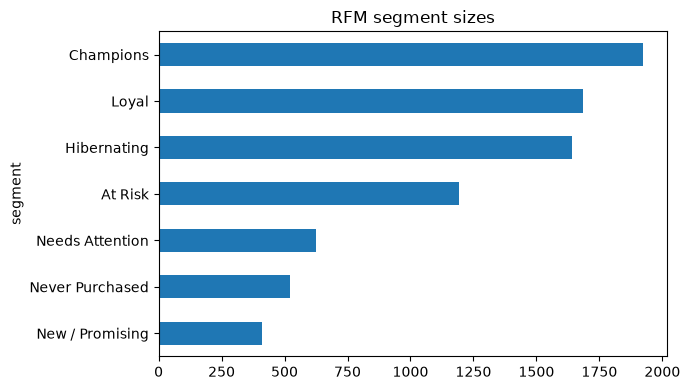

segment
Champions          1924
Loyal              1685
Hibernating        1641
At Risk            1191
Needs Attention     626
Never Purchased     523
New / Promising     410
Name: count, dtype: int64

In [2]:
sizes = scored['segment'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
sizes.sort_values().plot(kind='barh', ax=ax)
ax.set_title('RFM segment sizes')
plt.tight_layout()
plt.show()
sizes

## Segment profiling

Per guide section 13: profile before naming — these segments used standard RFM-quintile labels already, so this profiling step checks that the labels actually match the underlying behavior (revenue, frequency, recency) rather than assuming it.

In [3]:
profile = scored.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_recency_days=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
).round(1).sort_values('avg_monetary', ascending=False)
profile

,customers,avg_recency_days,avg_frequency,avg_monetary
segment,,,,
Champions,1924,11.3,32.5,1619.1
Loyal,1685,42.7,15.2,733.7
At Risk,1191,257.1,14.8,729.2
Needs Attention,626,134.7,4.1,252.0
New / Promising,410,14.7,4.1,197.9
Hibernating,1641,367.5,2.9,125.7
Never Purchased,523,NaN,0.0,0.0


## Does the RFM segment relate to forward-looking churn?

Sanity check: segments built purely from historical R/F/M (no peek at the future) should still separate customers who go on to churn in the next 90 days from those who don't — that's the whole point of RFM as a leading indicator.

In [4]:
horizon_end = cutoff + pd.Timedelta(days=config.CHURN_HORIZON_DAYS)
lookback_start = cutoff - pd.Timedelta(days=config.ACTIVE_LOOKBACK_DAYS)
qualifying = orders[orders['status'] == 'completed']
active_ids = set(qualifying[(qualifying['order_date'] > lookback_start) & (qualifying['order_date'] <= cutoff)]['customer_id'])
future_ids = set(qualifying[(qualifying['order_date'] > cutoff) & (qualifying['order_date'] <= horizon_end)]['customer_id'])
joined = scored[scored['customer_id'].isin(active_ids)].copy()
joined['churned'] = ~joined['customer_id'].isin(future_ids)
(joined.groupby('segment')['churned'].mean() * 100).round(1).sort_values(ascending=False)

segment
At Risk            87.5
Hibernating        77.1
Needs Attention    48.0
Loyal              29.4
New / Promising    25.6
Champions           6.8
Name: churned, dtype: float64